<a href="https://colab.research.google.com/github/sashajh2/itau-group4/blob/main/Ensemble_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import itertools
from typing import Tuple, Union, Sequence

In [17]:
### Threshold Calculation Functions ###

"""
Returns the score threshold for which there are no false
negatives with a lower score.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""

def min_fnr_threshold(probs, Y_val):
  pos_scores = probs[Y_val == 1]
  return pos_scores.min()


"""
Returns the score threshold for which there are no false
positives with a higher score.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""
def min_fpr_threshold(probs, Y_val):
  neg_scores = probs[Y_val == 0]
  return neg_scores.max()


"""
Returns the approximate score threshold that
maximizes accuracy.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""
def max_acc_threshold(probs, Y_val):
    best_acc = 0
    best_thresh_acc = None

    for t in np.arange(0.01, 1.0, 0.01):
        preds = (probs > t).astype(int)
        acc = accuracy_score(Y_val, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = t

    return best_thresh_acc

In [18]:
### Dataset Splitting Functions ###
"""
    Split (X, y) into train / validation / test sets with arbitrary ratios.

    Parameters
    ----------
    train_ratio, val_ratio, test_ratio : float, default 0.7 / 0.2 / 0.1
        Fractions (must sum to 1).  They are interpreted **relative to the whole
        dataset**, e.g. 0.1 means “10 % of all samples.”
    random_state : int, default 42
        Seed for reproducibility.
    stratify : bool, default True
        If True, keeps class proportions by stratifying on `y`.

    Returns
    -------
    X_train, X_val, X_test, y_train, y_val, y_test
"""
def split_data(
        X: Union[np.ndarray, Sequence],
        y: Union[np.ndarray, Sequence],
        *,
        train_ratio: float = 0.7,
        val_ratio:   float = 0.2,
        test_ratio:  float = 0.1,
        random_state: int = 42,
        stratify: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray,
           np.ndarray, np.ndarray, np.ndarray]:

    # --- Sanity checks ------------------------------------------------------
    total = train_ratio + val_ratio + test_ratio
    if not np.isclose(total, 1.0):
        raise ValueError(f"Ratios must sum to 1 (got {total:.3f}).")
    if min(train_ratio, val_ratio, test_ratio) < 0:
        raise ValueError("Ratios must be non-negative.")

    strat_full = y if stratify else None

    # --- first split: train vs. temp ---------------------------------------
    temp_ratio = val_ratio + test_ratio          # e.g. 0.30 in the 70/20/10 case

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=temp_ratio,
        random_state=random_state,
        shuffle=True,
        stratify=strat_full
    )

    # --- second split: val vs. test inside the temp chunk ------------------
    # test share *within* the temp chunk:
    test_share_of_temp = test_ratio / temp_ratio if temp_ratio > 0 else 0.0

    strat_temp = y_temp if stratify else None

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=test_share_of_temp,
        random_state=random_state,
        shuffle=True,
        stratify=strat_temp
    )

    return np.array(X_train), np.array(X_val), np.array(X_test), np.array(y_train), np.array(y_val), np.array(y_test)

In [61]:
class LogisticModule:
    def __init__(self, logistic_module):
        self.logistic_module = logistic_module
        self.threshold = 0.5 # Base Threshold for a logistic Regressor

    """
    Given training data and labels, train the logistic regression
    layer of the module.
    """
    def train_logistic_module(self, X_train, Y_train):
      clf = self.logistic_module
      clf.fit(X_train, Y_train)

    """
    Uses the validation set to obtain
    the threshold for classification, as described
    by a given function, for the logistic regressor.
    If no function is provided, the default is to use 0.5.

    Returns the computed threshold.
    """
    def set_threshold(self, X_val, Y_val, threshold_selection_fn=None):
      if threshold_selection_fn is None:
        self.threshold = 0.5
        return 0.5
      # Get the class-1 probabilities on *validation* data
      probs = self.logistic_module.predict_proba(X_val)[:, 1]

      threshold = threshold_selection_fn(probs, Y_val.ravel())

      # Update the threshold
      self.threshold = threshold
      return threshold

    """
    Tests the module and outputs accuracy, F1, and AUC.

    Will display confusion matrices.
    """
    def evaluate_module(self, X_test, Y_test, display_title=None):
      y_probs = self.logistic_module.predict_proba(X_test)[:,1]
      y_pred = (y_probs >= self.threshold).astype(int)

      # Compute confusion matrix
      cm = confusion_matrix(Y_test, y_pred)
      tn, fp, fn, tp = cm.ravel()

      # Display confusion matrix
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.logistic_module.classes_)
      disp.plot(cmap='Blues')
      plt.title(f"Confusion Matrix (threshold = {self.threshold})")
      plt.show()

      # Compute metrics
      roc_auc = roc_auc_score(Y_test, y_probs)
      f1 = f1_score(Y_test, y_pred)
      acc = accuracy_score(Y_test, y_pred)

      # Save metrics in a dictionary
      results = {"Accuracy" : acc, "F1": f1, "ROC AUC": roc_auc}
      return results

    """
    Predict the label of a given example/embedding x

    Must be in array-like format.
    """
    def predict_score(self, x):
      score = self.logistic_module.predict_proba(x)[:,1]
      return score[0]

    """
    Predict the label of a given example/embedding x

    Must be in array-like format.
    """
    def predict_label(self, x):
      label = self.logistic_module.predict_proba(x)[:,1]
      return int(label[0] > self.threshold)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


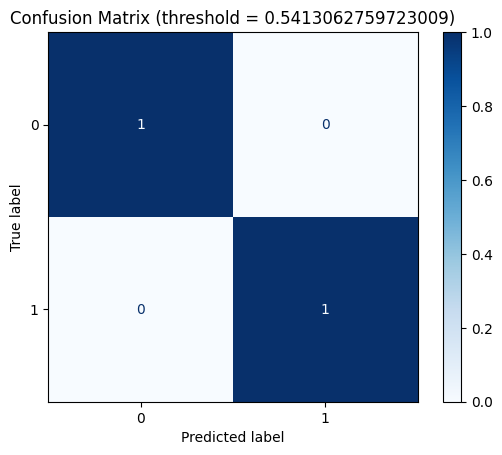

0.41202641522231653
0


In [64]:
### Example Code ###
video_dataset = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1, 1) # Embeddings
labels = np.array([0,0,0,0,0,1,1,1,1,1]).reshape(-1, 1) # Real - 0, Fake - 1
X_train, X_val, X_test, Y_train, Y_val, Y_test = split_data(video_dataset, labels)
logistic_regressor1 = LogisticRegression()
ensemble_layer1 = LogisticModule(logistic_regressor1)

# Train it on the dataset
ensemble_layer1.train_logistic_module(X_train, Y_train)

# Set the threshold
threshold_functions = [min_fnr_threshold, min_fpr_threshold, max_acc_threshold]

# Pick one of the three
thres_func = threshold_functions[0]
ensemble_layer1.set_threshold(X_val, Y_val, thres_func)

# Evaluate the model
ensemble_layer1.evaluate_module(X_test, Y_test)

# Predict score
print(ensemble_layer1.predict_score(np.array([[5.5]])))
print(ensemble_layer1.predict_label(np.array([[5.5]])))